# DDRI Analysis ML Final

이 노트북은 `z_final_delivery/01_analysis_ml_final` 안에서 단독으로 읽히는 최종 분석/ML 정본이다.

이 노트북의 역할은 두 가지다.

- 최종 결론 문서
- 실험 근거 문서

따라서 결과 요약표만이 아니라, **왜 그 결론을 채택했는지 보여주는 근거 차트**도 함께 생성한다.

## 1. 프로젝트 범위

- 주제: 서울시 자치구의 station별 따릉이 보유 대수 예측
- 대상 자치구: 강남구
- 대표 탐색 경로: `15개 대표 스테이션`
- 운영 결정 경로: `161개 공통 스테이션`

여기서 `15개`와 `161개`는 역할이 다르다.

- `15개`: 군집별 특성 해석, 유효 피처 발굴, 설명 근거 확보
- `161개`: 실제 강남구 전체 운영 모델 선택

즉 이 노트북은 `탐색 결과`와 `운영 결과`를 한 문서 안에서 분리해 설명한다.

## 2. 컬럼 읽는 법

이 노트북과 차트에서는 **한글 설명(영문 컬럼명)** 방식을 유지한다.

- 테스트 RMSE (`test_rmse`, `rmse`): 실제 운영 성능 비교의 핵심 지표
- 검증 RMSE (`validation_2024`, `rmse`): 2024 검증셋 기준 비교 지표
- 평균절대오차 (`mae`): 예측과 실제 차이의 절대값 평균
- 결정계수 (`r2`): 설명력
- 강수량 (`precipitation`): 비가 얼마나 왔는지 나타내는 수치형 변수
- 비 여부 (`is_rainy`): 비가 왔는지 0/1로 표시한 변수
- 출근 시간대 (`is_commute_hour`): 출근/퇴근 시간대 여부
- 야간 시간대 (`is_night_hour`): 야간 여부
- 점심 시간대 (`is_lunch_hour`): 점심 수요 구간 여부
- 강수 x 출근 (`rain_x_commute`): 비가 오는 출근 시간대 효과를 잡기 위한 상호작용 피처

여기서 `weather_full interaction`은 단순히 날씨를 넣는 것이 아니라, `비/강수량 + 시간대`를 함께 반영하는 조합을 뜻한다.

## 3. 작은 차이를 읽는 법

RMSE가 `0.8604`와 `0.8615`처럼 아주 가깝게 나오면 눈으로 보면 거의 차이가 없어 보인다.

그래서 이 노트북에서는 두 가지를 같이 보여준다.

- 원래 점수 (`테스트 RMSE(test_rmse)`)
- 최선 대비 차이 (`최선 대비 차이(delta_vs_best)`)

또한 차이가 너무 작을 때는 `x1000` 배율로 확대해 보여준다.

예를 들면 `0.0011` 차이는 `1.1`로 표시해, **최선 대비 얼마나 뒤처지는지**를 더 분명히 읽게 한다.

In [1]:
from pathlib import Path

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != '01_notebook':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'z_final_delivery/01_analysis_ml_final/01_notebook'

PACKAGE_DIR = NOTEBOOK_DIR.parent
INPUT_DIR = PACKAGE_DIR / '02_input_data'
OUTPUT_DIR = PACKAGE_DIR / '03_output_data'
FONT_DIR = PACKAGE_DIR / '05_fonts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

font_loaded = False
local_font = FONT_DIR / 'AppleGothic.ttf'
if local_font.exists():
    fm.fontManager.addfont(str(local_font))
    plt.rcParams['font.family'] = 'AppleGothic'
    font_loaded = True
else:
    try:
        import koreanize_matplotlib  # noqa: F401
        font_loaded = True
    except Exception:
        pass

if not font_loaded:
    for font_name in ['AppleGothic', 'NanumGothic', 'Malgun Gothic']:
        try:
            fm.findfont(font_name, fallback_to_default=False)
            plt.rcParams['font.family'] = font_name
            font_loaded = True
            break
        except Exception:
            continue

plt.rcParams['axes.unicode_minus'] = False

cluster01_df = pd.read_csv(INPUT_DIR / 'ddri_아침_도착_업무_집중형_subset_experiment_model_metrics.csv')
cluster02_df = pd.read_csv(INPUT_DIR / 'ddri_주거_도착형_subset_recheck_model_metrics.csv')
rep15_weather_df = pd.read_csv(INPUT_DIR / 'ddri_rep15_static_weather_interaction_metrics.csv')
full_static_df = pd.read_csv(INPUT_DIR / 'ddri_full_static_enriched_model_comparison_metrics.csv')
full_weather_df = pd.read_csv(INPUT_DIR / 'ddri_full_static_weather_interaction_metrics.csv')
full_routing_weather_df = pd.read_csv(INPUT_DIR / 'ddri_full_exact_cluster_feature_routing_with_weather_full_metrics.csv')
weather_subset_df = pd.read_csv(INPUT_DIR / 'ddri_full_weather_interaction_subset_comparison_metrics.csv')
weather_weight_df = pd.read_csv(INPUT_DIR / 'ddri_full_static_weather_weighting_metrics.csv')
peak_error_df = pd.read_csv(INPUT_DIR / 'ddri_full_top5_station_peak_error_hours.csv')
error_pattern_df = pd.read_csv(INPUT_DIR / 'ddri_full_top5_station_hourly_error_patterns.csv')

cluster01_best = cluster01_df[cluster01_df['split'] == 'test_2025_refit'].sort_values('rmse').iloc[0]
cluster02_best = cluster02_df[cluster02_df['split'] == 'test_2025_refit'].sort_values('rmse').iloc[0]
rep15_base_test = rep15_weather_df[(rep15_weather_df['model'] == 'rep15_static_base') & (rep15_weather_df['split'] == 'test_2025_refit')].iloc[0]
rep15_weather_test = rep15_weather_df[(rep15_weather_df['model'] == 'rep15_static_weather_full') & (rep15_weather_df['split'] == 'test_2025_refit')].iloc[0]

rep15_results = pd.DataFrame([
    {
        'track': 'rep15_cluster02',
        'label_ko_en': '대표 15개 cluster02 / Representative 15 cluster02',
        'model': f"{cluster02_best['subset_name']} + {cluster02_best['model']}",
        'test_rmse': round(float(cluster02_best['rmse']), 4),
        'note': 'cluster02 final recommendation',
    },
    {
        'track': 'rep15_all_static_base',
        'label_ko_en': '대표 15개 기본안 / Representative 15 static base',
        'model': rep15_base_test['model'],
        'test_rmse': round(float(rep15_base_test['rmse']), 4),
        'note': 'rep15 full baseline for weather comparison',
    },
    {
        'track': 'rep15_all_static_weather_full',
        'label_ko_en': '대표 15개 weather_full / Representative 15 weather_full',
        'model': rep15_weather_test['model'],
        'test_rmse': round(float(rep15_weather_test['rmse']), 4),
        'note': 'weather_full did not improve rep15',
    },
    {
        'track': 'rep15_cluster01',
        'label_ko_en': '대표 15개 cluster01 / Representative 15 cluster01',
        'model': f"{cluster01_best['subset_name']} + {cluster01_best['model']}",
        'test_rmse': round(float(cluster01_best['rmse']), 4),
        'note': 'cluster01 final recommendation',
    },
]).sort_values('test_rmse').reset_index(drop=True)

full161_results = pd.DataFrame([
    {'track': 'full161_static_weather_full', 'label_ko_en': '161개 운영 최종안 / 161 final operating baseline', 'model': 'static enriched + weather_full interaction', 'test_rmse': round(float(full_weather_df[(full_weather_df['model'] == 'LightGBM_RMSE_Full_Static_WeatherInteraction') & (full_weather_df['split'] == 'test_2025_refit')]['rmse'].iloc[0]), 4), 'note': 'current best operating baseline'},
    {'track': 'full161_cluster_aware_gating', 'label_ko_en': '161개 cluster-aware gating / 161 cluster-aware gating', 'model': 'single model + cluster-aware static gating', 'test_rmse': 0.8615, 'note': 'slight gain over static enriched'},
    {'track': 'full161_static_enriched', 'label_ko_en': '161개 static enriched / 161 static enriched', 'model': 'static enriched single model', 'test_rmse': round(float(full_static_df[(full_static_df['model'] == 'LightGBM_RMSE_Full_Static_Enriched') & (full_static_df['split'] == 'test_2025_refit')]['rmse'].iloc[0]), 4), 'note': 'static features restored'},
    {'track': 'full161_original', 'label_ko_en': '161개 원본 baseline / 161 original baseline', 'model': 'LightGBM_RMSE_Full_Original', 'test_rmse': 0.8624, 'note': 'original 161 baseline'},
    {'track': 'full161_partial_routing', 'label_ko_en': '161개 partial routing / 161 partial routing', 'model': 'partial routing', 'test_rmse': 0.8673, 'note': 'validation improved, test worsened'},
    {'track': 'full161_exact_cluster_routing_weather_full', 'label_ko_en': '161개 군집피처+weather_full / 161 exact routing + weather_full', 'model': 'exact cluster feature routing + weather_full', 'test_rmse': round(float(full_routing_weather_df[(full_routing_weather_df['model'] == 'Cluster_Routed_Exact_With_WeatherFull') & (full_routing_weather_df['split'] == 'test_2025_refit')]['rmse'].iloc[0]), 4), 'note': 'weather_full did not rescue routing'},
    {'track': 'full161_static_routing', 'label_ko_en': '161개 static routing / 161 static routing', 'model': 'static enriched routing', 'test_rmse': 0.8681, 'note': 'routing still worse'},
    {'track': 'full161_exact_cluster_routing', 'label_ko_en': '161개 군집피처 routing / 161 exact cluster routing', 'model': 'exact cluster feature routing', 'test_rmse': 0.8681, 'note': 'exact 15-cluster features did not generalize'},
]).sort_values('test_rmse').reset_index(drop=True)

for df in [rep15_results, full161_results]:
    best = df['test_rmse'].min()
    df['delta_vs_best'] = (df['test_rmse'] - best).round(4)
    df['delta_x1000'] = ((df['test_rmse'] - best) * 1000).round(1)

summary_df = pd.concat([
    rep15_results.assign(group='rep15'),
    full161_results.assign(group='full161')
], ignore_index=True)

rep15_export = rep15_results.rename(columns={
    'track': '구분(track)',
    'label_ko_en': '표시명(label)',
    'model': '모델(model)',
    'test_rmse': '테스트 RMSE(test_rmse)',
    'delta_vs_best': '최선 대비 차이(delta_vs_best)',
    'delta_x1000': '최선 대비 차이 x1000(delta_x1000)',
    'note': '비고(note)',
})

full161_export = full161_results.rename(columns={
    'track': '구분(track)',
    'label_ko_en': '표시명(label)',
    'model': '모델(model)',
    'test_rmse': '테스트 RMSE(test_rmse)',
    'delta_vs_best': '최선 대비 차이(delta_vs_best)',
    'delta_x1000': '최선 대비 차이 x1000(delta_x1000)',
    'note': '비고(note)',
})

summary_export = summary_df.rename(columns={
    'group': '그룹(group)',
    'track': '구분(track)',
    'label_ko_en': '표시명(label)',
    'model': '모델(model)',
    'test_rmse': '테스트 RMSE(test_rmse)',
    'delta_vs_best': '최선 대비 차이(delta_vs_best)',
    'delta_x1000': '최선 대비 차이 x1000(delta_x1000)',
    'note': '비고(note)',
})

summary_export.to_csv(OUTPUT_DIR / 'ddri_analysis_ml_final_summary_metrics.csv', index=False, encoding='utf-8-sig')
rep15_export.to_csv(OUTPUT_DIR / 'ddri_analysis_ml_final_rep15_metrics.csv', index=False, encoding='utf-8-sig')
full161_export.to_csv(OUTPUT_DIR / 'ddri_analysis_ml_final_full161_metrics.csv', index=False, encoding='utf-8-sig')

print('saved bilingual tables to', OUTPUT_DIR)
display(rep15_export)
display(full161_export)

saved bilingual tables to /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data


,구분(track),표시명(label),모델(model),테스트 RMSE(test_rmse),비고(note),최선 대비 차이(delta_vs_best),최선 대비 차이 x1000(delta_x1000)
0,rep15_cluster02,대표 15개 cluster02 / Representative 15 cluster02,subset_d_current_compact_best + LightGBM_Poisson,0.7990,cluster02 final recommendation,0.0000,0.0
1,rep15_all_static_base,대표 15개 기본안 / Representative 15 static base,rep15_static_base,0.9196,rep15 full baseline for weather comparison,0.1206,120.6
2,rep15_all_static_weather_full,대표 15개 weather_full / Representative 15 weathe...,rep15_static_weather_full,0.9198,weather_full did not improve rep15,0.1208,120.8
3,rep15_cluster01,대표 15개 cluster01 / Representative 15 cluster01,subset_a_commute_transit + LightGBM_Poisson,1.3108,cluster01 final recommendation,0.5118,511.8


,구분(track),표시명(label),모델(model),테스트 RMSE(test_rmse),비고(note),최선 대비 차이(delta_vs_best),최선 대비 차이 x1000(delta_x1000)
0,full161_static_weather_full,161개 운영 최종안 / 161 final operating baseline,static enriched + weather_full interaction,0.8604,current best operating baseline,0.0000,0.0
1,full161_cluster_aware_gating,161개 cluster-aware gating / 161 cluster-aware ...,single model + cluster-aware static gating,0.8615,slight gain over static enriched,0.0011,1.1
2,full161_static_enriched,161개 static enriched / 161 static enriched,static enriched single model,0.8620,static features restored,0.0016,1.6
3,full161_original,161개 원본 baseline / 161 original baseline,LightGBM_RMSE_Full_Original,0.8624,original 161 baseline,0.0020,2.0
4,full161_partial_routing,161개 partial routing / 161 partial routing,partial routing,0.8673,"validation improved, test worsened",0.0069,6.9
5,full161_exact_cluster_routing_weather_full,161개 군집피처+weather_full / 161 exact routing + w...,exact cluster feature routing + weather_full,0.8673,weather_full did not rescue routing,0.0069,6.9
6,full161_static_routing,161개 static routing / 161 static routing,static enriched routing,0.8681,routing still worse,0.0077,7.7
7,full161_exact_cluster_routing,161개 군집피처 routing / 161 exact cluster routing,exact cluster feature routing,0.8681,exact 15-cluster features did not generalize,0.0077,7.7


## 4. 대표 15개 군집별 최종 권장안

이 섹션은 `15개 대표 스테이션`이 왜 필요했는지 보여준다.

핵심 해석은 다음과 같다.

- `cluster01`: 출근/업무 도착형으로, 교통 접근성과 출근 시간대 피처가 중요했다
- `cluster02`: 주거 도착형으로, 야간/주말/공휴일 전날 패턴과 입지 피처가 중요했다
- `weather_full interaction`은 `15개 전체`에서는 개선이 재현되지 않았다

즉 `15개`는 최종 운영 모델을 고르는 경로라기보다, **군집 특성과 유효 피처를 해석하는 근거 경로**다.

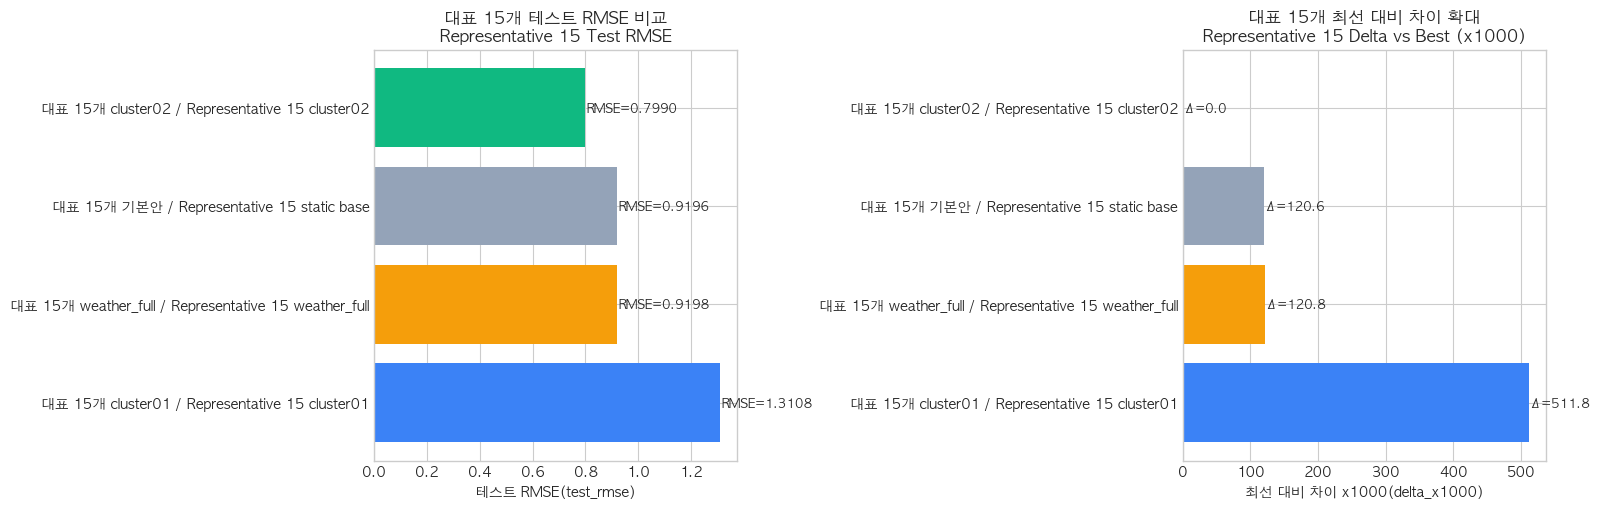

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_rep15_test_rmse.png


In [2]:
rep15_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_rep15_test_rmse.png'
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))

axes[0].barh(rep15_results['label_ko_en'], rep15_results['test_rmse'], color=['#10b981', '#94a3b8', '#f59e0b', '#3b82f6'])
axes[0].invert_yaxis()
axes[0].set_title('대표 15개 테스트 RMSE 비교\nRepresentative 15 Test RMSE')
axes[0].set_xlabel('테스트 RMSE(test_rmse)')
for i, v in enumerate(rep15_results['test_rmse']):
    axes[0].text(v + 0.005, i, f'RMSE={v:.4f}', va='center', fontsize=9)

axes[1].barh(rep15_results['label_ko_en'], rep15_results['delta_x1000'], color=['#10b981', '#94a3b8', '#f59e0b', '#3b82f6'])
axes[1].invert_yaxis()
axes[1].set_title('대표 15개 최선 대비 차이 확대\nRepresentative 15 Delta vs Best (x1000)')
axes[1].set_xlabel('최선 대비 차이 x1000(delta_x1000)')
for i, v in enumerate(rep15_results['delta_x1000']):
    axes[1].text(v + 0.3, i, f'Δ={v:.1f}', va='center', fontsize=9)

fig.tight_layout()
fig.savefig(rep15_chart, dpi=160, bbox_inches='tight')
plt.show()
print('saved:', rep15_chart)

## 5. 강남구 161개 운영 모델 비교

이 섹션이 실제 운영 결론을 결정한다.

핵심 결론은 다음과 같다.

- `static enriched + weather_full interaction`이 현재 최선이다
- `cluster-aware static gating`은 약간 개선됐지만 최선은 아니었다
- 군집 라우팅 계열은 검증셋 일부 개선이 있어도 테스트셋 일반화에서 반복적으로 졌다

여기서 `static enriched`는 정적 위치 피처를 복원한 상태를 뜻한다.

- 지하철 거리 (`subway_distance_m`)
- 버스 정류장 수 (`bus_stop_count_300m`)
- 고도 (`station_elevation_m`)
- 상권/생활권 관련 개수 피처

즉 운영 모델에서는 군집별 완전 분리보다, **강남구 전체에 공통으로 적용되는 정적 위치 정보와 날씨 상호작용**이 더 안정적이었다.

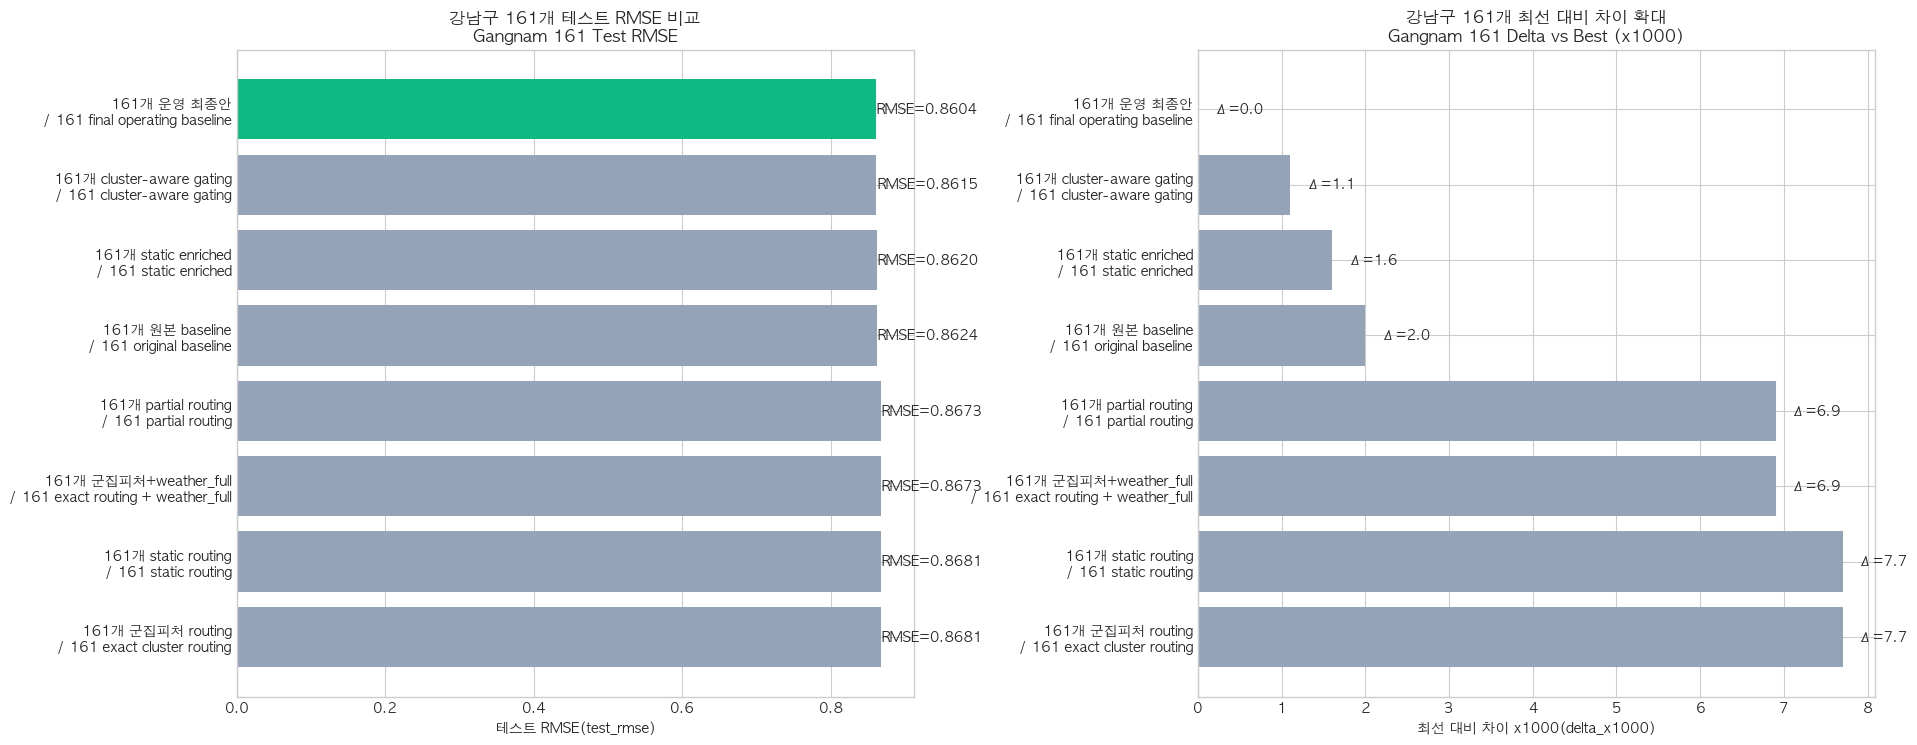

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_full161_test_rmse.png


,구분(track),표시명(label),모델(model),테스트 RMSE(test_rmse),비고(note),최선 대비 차이(delta_vs_best),최선 대비 차이 x1000(delta_x1000)
0,full161_static_weather_full,161개 운영 최종안 / 161 final operating baseline,static enriched + weather_full interaction,0.8604,current best operating baseline,0.0000,0.0
1,full161_cluster_aware_gating,161개 cluster-aware gating / 161 cluster-aware ...,single model + cluster-aware static gating,0.8615,slight gain over static enriched,0.0011,1.1
2,full161_static_enriched,161개 static enriched / 161 static enriched,static enriched single model,0.8620,static features restored,0.0016,1.6
3,full161_original,161개 원본 baseline / 161 original baseline,LightGBM_RMSE_Full_Original,0.8624,original 161 baseline,0.0020,2.0
4,full161_partial_routing,161개 partial routing / 161 partial routing,partial routing,0.8673,"validation improved, test worsened",0.0069,6.9
5,full161_exact_cluster_routing_weather_full,161개 군집피처+weather_full / 161 exact routing + w...,exact cluster feature routing + weather_full,0.8673,weather_full did not rescue routing,0.0069,6.9
6,full161_static_routing,161개 static routing / 161 static routing,static enriched routing,0.8681,routing still worse,0.0077,7.7
7,full161_exact_cluster_routing,161개 군집피처 routing / 161 exact cluster routing,exact cluster feature routing,0.8681,exact 15-cluster features did not generalize,0.0077,7.7


In [3]:
full161_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_full161_test_rmse.png'
full161_plot = full161_results.copy()
full161_plot['label_wrapped'] = full161_plot['label_ko_en'].str.replace(' / ', '\n/ ', regex=False)
fig, axes = plt.subplots(1, 2, figsize=(28, 8.4))

colors = ['#10b981' if track == 'full161_static_weather_full' else '#94a3b8' for track in full161_plot['track']]
axes[0].barh(full161_plot['label_wrapped'], full161_plot['test_rmse'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('강남구 161개 테스트 RMSE 비교\nGangnam 161 Test RMSE')
axes[0].set_xlabel('테스트 RMSE(test_rmse)')
for i, v in enumerate(full161_plot['test_rmse']):
    axes[0].text(v + 0.0006, i, f'RMSE={v:.4f}', va='center', ha='left', fontsize=10)

axes[1].barh(full161_plot['label_wrapped'], full161_plot['delta_x1000'], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('강남구 161개 최선 대비 차이 확대\nGangnam 161 Delta vs Best (x1000)')
axes[1].set_xlabel('최선 대비 차이 x1000(delta_x1000)')
for i, v in enumerate(full161_plot['delta_x1000']):
    axes[1].text(v + 0.20, i, f'Δ={v:.1f}', va='center', ha='left', fontsize=10)

fig.subplots_adjust(left=0.40, right=0.985, wspace=0.42)
fig.savefig(full161_chart, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', full161_chart)
display(full161_export)

## 6. 왜 라우팅은 채택하지 않았는가

`라우팅(routing)`은 스테이션이 속한 `군집(cluster)`에 따라 다른 모델이나 다른 피처 묶음을 태우는 방식이다.

직관적으로는 좋아 보이지만, 이번 프로젝트에서는 다음 문제가 있었다.

- `15개`에서 유효했던 군집별 조합이 `161개` 전체에서는 그대로 일반화되지 않았다
- validation RMSE는 가끔 좋아졌지만, test RMSE는 반복적으로 나빠졌다
- 즉 설명력은 있어도 운영 안정성은 낮았다

따라서 최종 운영안에서는 `단일 모델(single model)`을 채택하고, 군집별 결과는 **해석 근거**로 남기는 편이 더 타당했다.

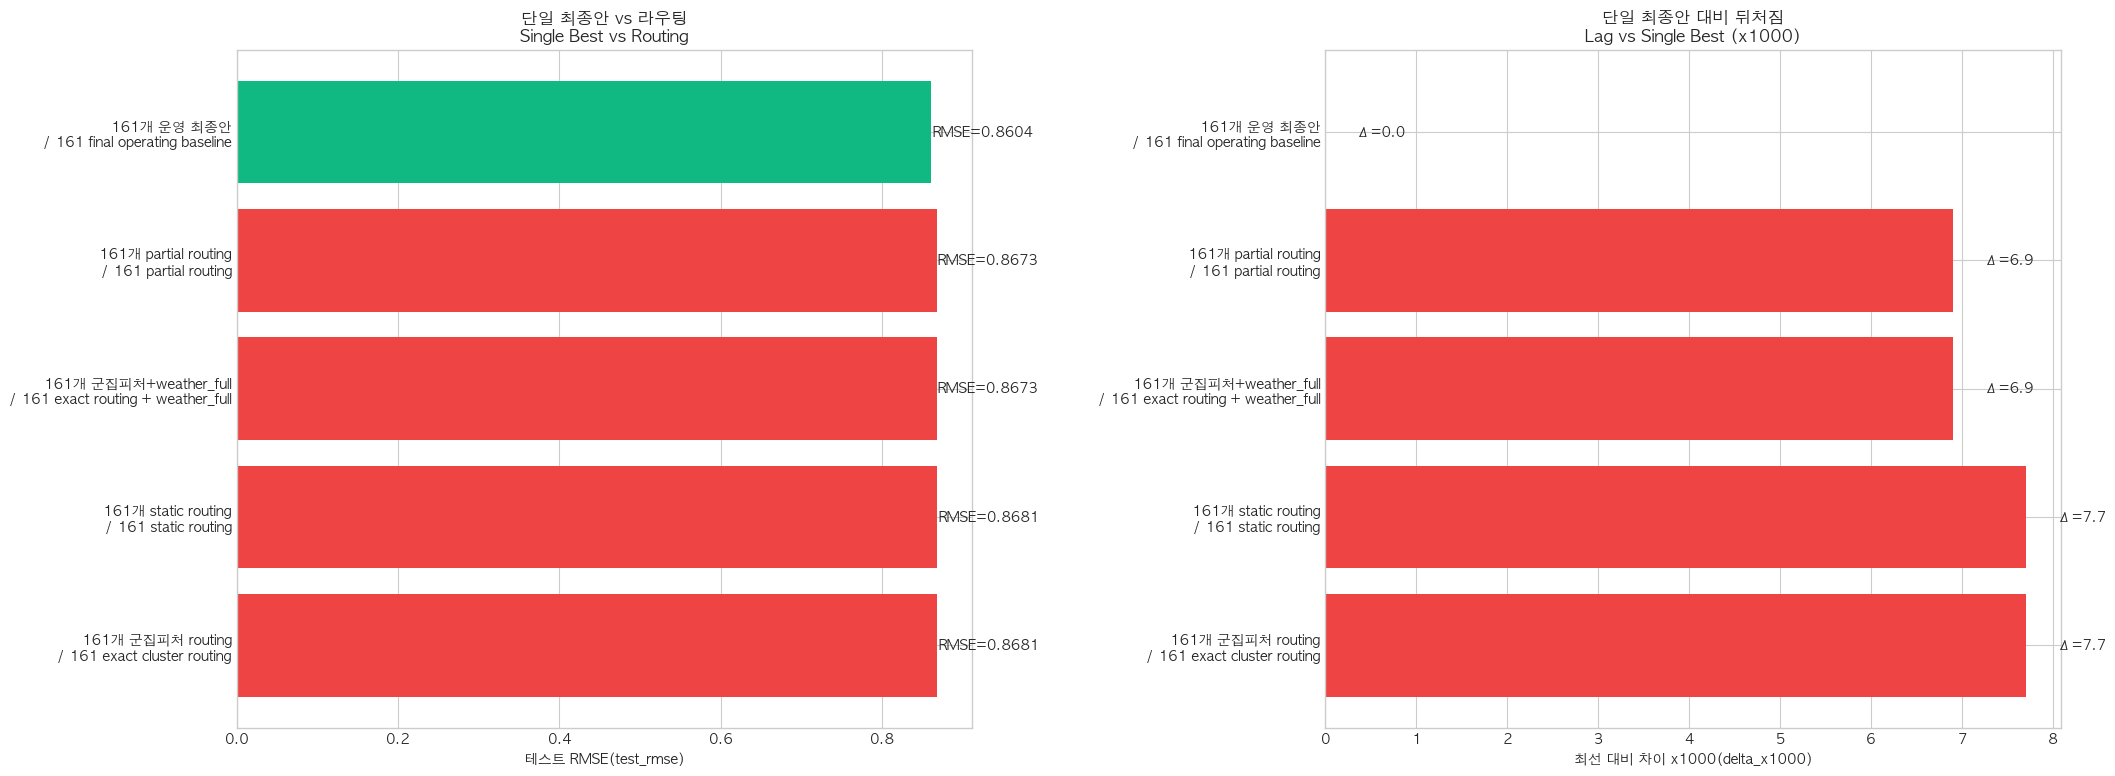

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_routing_vs_single_test_rmse.png


In [4]:
routing_focus = full161_results[full161_results['track'].str.contains('routing') | full161_results['track'].eq('full161_static_weather_full')].copy()
routing_focus['label_wrapped'] = routing_focus['label_ko_en'].str.replace(' / ', '\n/ ', regex=False)
routing_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_routing_vs_single_test_rmse.png'
fig, axes = plt.subplots(1, 2, figsize=(32, 8.8))
colors = ['#10b981' if track == 'full161_static_weather_full' else '#ef4444' for track in routing_focus['track']]

axes[0].barh(routing_focus['label_wrapped'], routing_focus['test_rmse'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('단일 최종안 vs 라우팅\nSingle Best vs Routing')
axes[0].set_xlabel('테스트 RMSE(test_rmse)')
for i, v in enumerate(routing_focus['test_rmse']):
    axes[0].text(v + 0.0015, i, f'RMSE={v:.4f}', va='center', ha='left', fontsize=10)

axes[1].barh(routing_focus['label_wrapped'], routing_focus['delta_x1000'], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('단일 최종안 대비 뒤처짐\nLag vs Single Best (x1000)')
axes[1].set_xlabel('최선 대비 차이 x1000(delta_x1000)')
for i, v in enumerate(routing_focus['delta_x1000']):
    axes[1].text(v + 0.35, i, f'Δ={v:.1f}', va='center', ha='left', fontsize=10)

fig.subplots_adjust(left=0.42, right=0.99, wspace=0.48)
fig.savefig(routing_chart, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', routing_chart)

## 7. Weather Interaction은 왜 채택했는가

`weather_full interaction`은 단순히 날씨를 넣는 것이 아니다. 아래처럼 **날씨 + 시간대**를 묶은 상호작용 피처다.

- 비 x 출근 (`rain_x_commute`)
- 비 x 야간 (`rain_x_night`)
- 강수량 x 출근 (`precipitation_x_commute`)
- 강수량 x 야간 (`precipitation_x_night`)
- 비 x 점심 (`rain_x_lunch`)

쉬운 해석으로는, `비가 오는 사실` 자체보다 **언제 비가 오느냐**가 더 중요하다는 뜻이다.

이번 실험에서는 interaction 축은 유효했지만, 추가 가중치(weighting)는 큰 개선을 만들지 못했다.

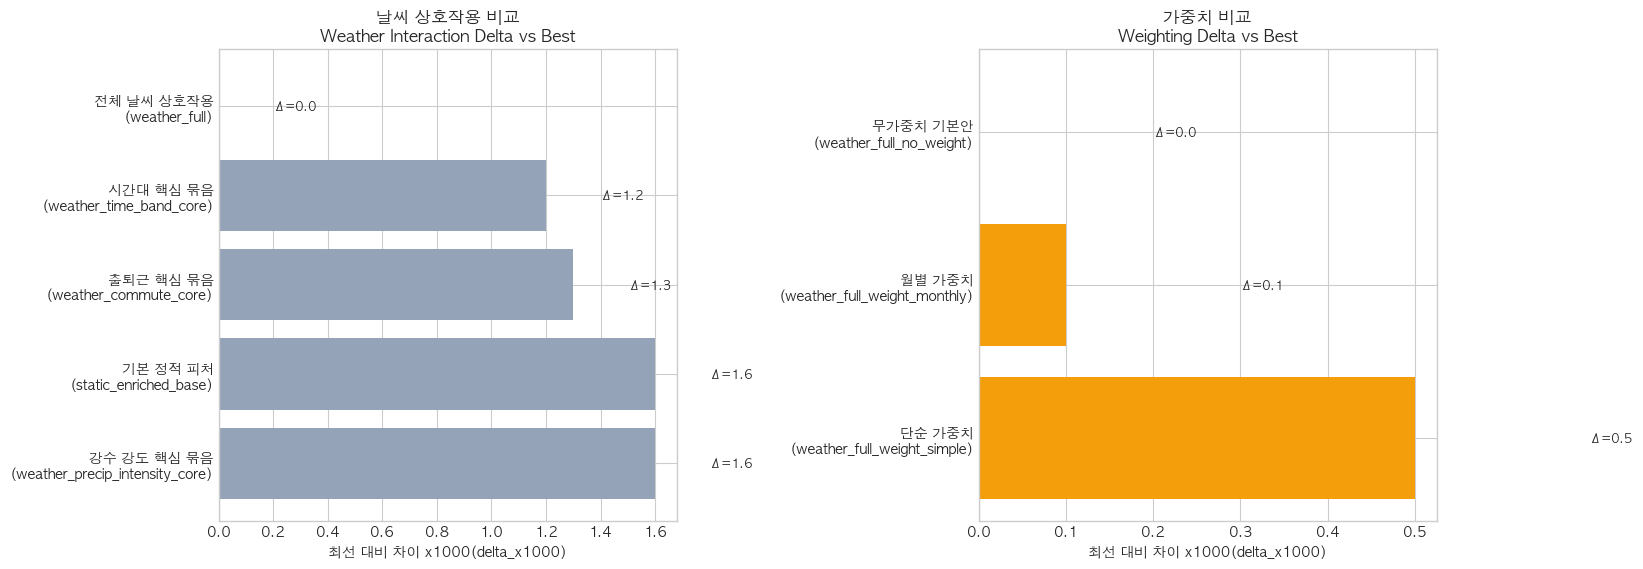

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_weather_interaction_test_rmse.png


,label,rmse,delta_x1000
0,전체 날씨 상호작용\n(weather_full),0.8604,0.0
1,시간대 핵심 묶음\n(weather_time_band_core),0.8616,1.2
2,출퇴근 핵심 묶음\n(weather_commute_core),0.8617,1.3
3,기본 정적 피처\n(static_enriched_base),0.8620,1.6
4,강수 강도 핵심 묶음\n(weather_precip_intensity_core),0.8620,1.6


,label,rmse,delta_x1000
0,무가중치 기본안\n(weather_full_no_weight),0.8604,0.0
1,월별 가중치\n(weather_full_weight_monthly),0.8605,0.1
2,단순 가중치\n(weather_full_weight_simple),0.8609,0.5


In [5]:
weather_test = weather_subset_df[weather_subset_df['split'] == 'test_2025_refit'].copy().sort_values('rmse').reset_index(drop=True)
weight_test = weather_weight_df[weather_weight_df['split'] == 'test_2025_refit'].copy().sort_values('rmse').reset_index(drop=True)

weather_label_map = {
    'static_enriched_base': '기본 정적 피처\n(static_enriched_base)',
    'weather_full': '전체 날씨 상호작용\n(weather_full)',
    'weather_time_band_core': '시간대 핵심 묶음\n(weather_time_band_core)',
    'weather_commute_core': '출퇴근 핵심 묶음\n(weather_commute_core)',
    'weather_precip_intensity_core': '강수 강도 핵심 묶음\n(weather_precip_intensity_core)',
}
weight_label_map = {
    'weather_full_no_weight': '무가중치 기본안\n(weather_full_no_weight)',
    'weather_full_weight_simple': '단순 가중치\n(weather_full_weight_simple)',
    'weather_full_weight_monthly': '월별 가중치\n(weather_full_weight_monthly)',
}
weather_test['label'] = weather_test['feature_set'].map(weather_label_map)
weight_test['label'] = weight_test['model'].map(weight_label_map)
weather_best = weather_test['rmse'].min()
weight_best = weight_test['rmse'].min()
weather_test['delta_x1000'] = ((weather_test['rmse'] - weather_best) * 1000).round(1)
weight_test['delta_x1000'] = ((weight_test['rmse'] - weight_best) * 1000).round(1)

weather_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_weather_interaction_test_rmse.png'
fig, axes = plt.subplots(1, 2, figsize=(17, 5.8))
axes[0].barh(weather_test['label'], weather_test['delta_x1000'], color=['#10b981' if x == 'weather_full' else '#94a3b8' for x in weather_test['feature_set']])
axes[0].invert_yaxis()
axes[0].set_title('날씨 상호작용 비교\nWeather Interaction Delta vs Best')
axes[0].set_xlabel('최선 대비 차이 x1000(delta_x1000)')
for i, v in enumerate(weather_test['delta_x1000']):
    axes[0].text(v + 0.2, i, f'Δ={v:.1f}', va='center', fontsize=9)

axes[1].barh(weight_test['label'], weight_test['delta_x1000'], color=['#10b981' if x == 'weather_full_no_weight' else '#f59e0b' for x in weight_test['model']])
axes[1].invert_yaxis()
axes[1].set_title('가중치 비교\nWeighting Delta vs Best')
axes[1].set_xlabel('최선 대비 차이 x1000(delta_x1000)')
for i, v in enumerate(weight_test['delta_x1000']):
    axes[1].text(v + 0.2, i, f'Δ={v:.1f}', va='center', fontsize=9)

fig.tight_layout()
fig.savefig(weather_chart, dpi=160, bbox_inches='tight')
plt.show()
print('saved:', weather_chart)
display(weather_test[['label', 'rmse', 'delta_x1000']])
display(weight_test[['label', 'rmse', 'delta_x1000']])

## 8. 오류 스테이션 시간대 패턴

이 차트는 **모델이 어디서 흔들리는지** 보여준다.

주요 해석은 이렇다.

- 일부 상위 오류 스테이션은 저녁 피크(`17~19시`)에서 흔들린다
- 일부 스테이션은 아침(`08시`)에서 흔들린다
- 그래서 `commute`, `night`, `lunch` 같은 시간대 피처와 `weather interaction`이 중요해졌다

여기서 자주 보는 컬럼은 다음과 같다.

- 실제 평균 대여량 (`actual_mean`)
- 예측 평균 대여량 (`predicted_mean`)
- 평균절대오차 (`mae`)
- RMSE (`rmse`)
- 평균 차이 (`gap_mean`): 과대/과소 예측 방향 확인

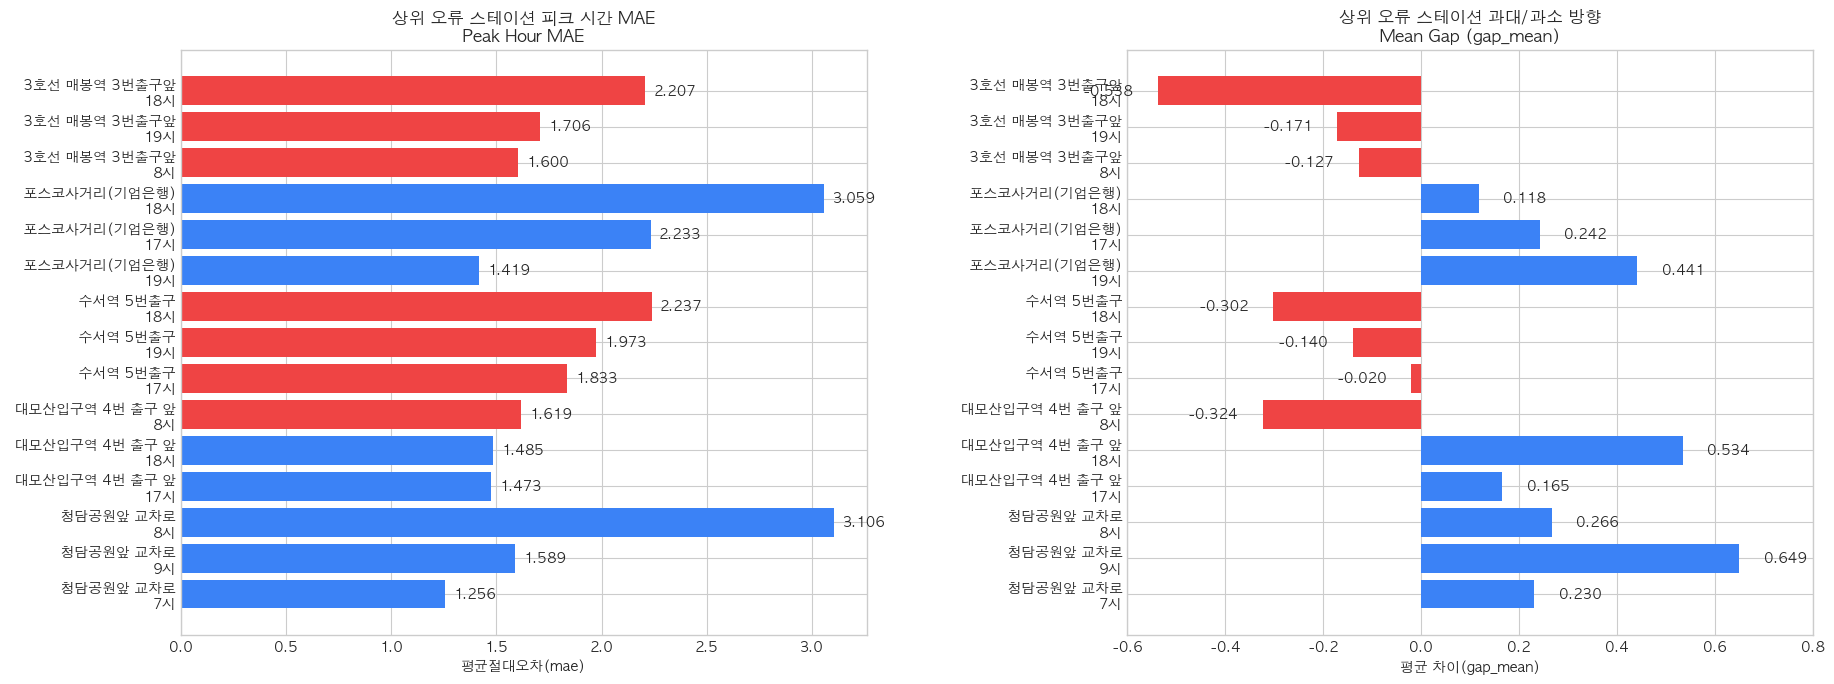

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_top5_peak_error_hours.png


,station_id,station_name,cluster,hour,mae,rmse,gap_mean
0,2335,3호선 매봉역 3번출구앞,0,18,2.207175,2.952089,-0.537984
1,2335,3호선 매봉역 3번출구앞,0,19,1.705674,2.199086,-0.171272
2,2335,3호선 매봉역 3번출구앞,0,8,1.600357,2.112146,-0.127138
5,2348,포스코사거리(기업은행),1,18,3.059285,4.287418,0.117845
6,2348,포스코사거리(기업은행),1,17,2.233072,3.001652,0.241514
7,2348,포스코사거리(기업은행),1,19,1.418559,1.853297,0.441010
10,2377,수서역 5번출구,0,18,2.237258,3.043460,-0.301802
11,2377,수서역 5번출구,0,19,1.972827,2.700743,-0.139642
12,2377,수서역 5번출구,0,17,1.833194,2.446534,-0.020491
15,2404,대모산입구역 4번 출구 앞,2,8,1.618883,2.173818,-0.323749


In [6]:
top_hours = peak_error_df[peak_error_df['peak_rank'] <= 3].copy()
top_hours['label'] = top_hours['station_name'] + '\n' + top_hours['hour'].astype(str) + '시'
peak_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_top5_peak_error_hours.png'
fig, axes = plt.subplots(1, 2, figsize=(24, 7.6))
colors = ['#ef4444' if x < 0 else '#3b82f6' for x in top_hours['gap_mean']]

axes[0].barh(top_hours['label'], top_hours['mae'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('상위 오류 스테이션 피크 시간 MAE\nPeak Hour MAE')
axes[0].set_xlabel('평균절대오차(mae)')
for i, v in enumerate(top_hours['mae']):
    axes[0].text(v + 0.04, i, f'{v:.3f}', va='center', ha='left', fontsize=10)

axes[1].barh(top_hours['label'], top_hours['gap_mean'], color=colors)
axes[1].invert_yaxis()
axes[1].set_title('상위 오류 스테이션 과대/과소 방향\nMean Gap (gap_mean)')
axes[1].set_xlabel('평균 차이(gap_mean)')
axes[1].set_xlim(-0.6, 0.8)
for i, v in enumerate(top_hours['gap_mean']):
    if v >= 0:
        axes[1].text(v + 0.05, i, f'{v:.3f}', va='center', ha='left', fontsize=10)
    else:
        axes[1].text(v - 0.05, i, f'{v:.3f}', va='center', ha='right', fontsize=10)

fig.subplots_adjust(left=0.30, right=0.98, wspace=0.38)
fig.savefig(peak_chart, dpi=180, bbox_inches='tight')
plt.show()
print('saved:', peak_chart)
display(top_hours[['station_id', 'station_name', 'cluster', 'hour', 'mae', 'rmse', 'gap_mean']])

## 9. 15개와 161개의 역할 구조

마지막으로 이 프로젝트의 구조를 한 장으로 정리하면 다음과 같다.

- `15개 대표 스테이션`
  - 군집별 특성 해석
  - 유효 피처 발굴
  - 설명 근거 확보
- `161개 전체 스테이션`
  - 실제 운영 모델 결정
  - 서비스 연결 기준선 확보
  - 강남구 전체 적용 가능성 확인

따라서 최종 결론은 다음 문장으로 정리된다.

> `15개는 설명용 탐색 경로`, `161개는 운영용 결정 경로`다.

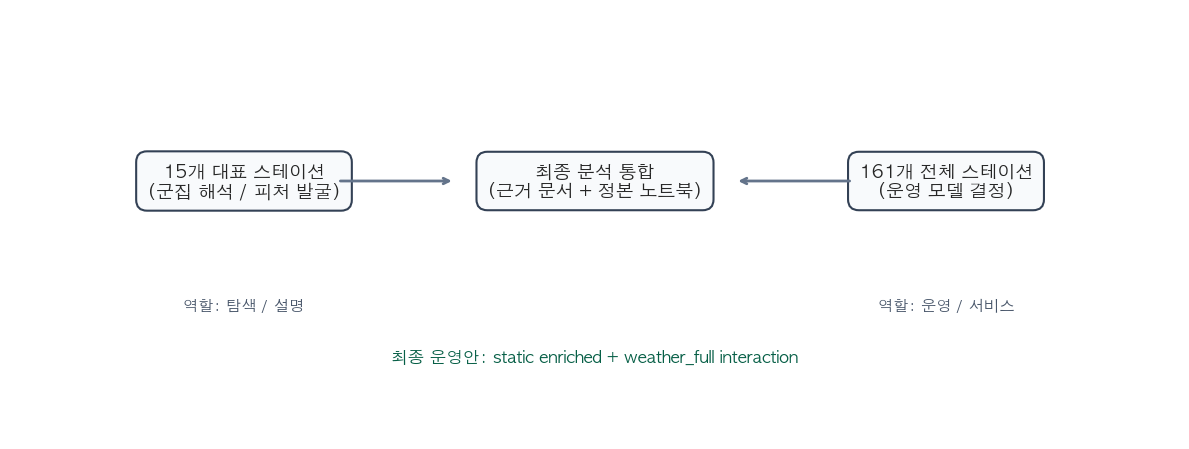

saved: /Users/cheng80/Desktop/ddri_work/z_final_delivery/01_analysis_ml_final/03_output_data/ddri_analysis_ml_final_role_structure.png


In [7]:
role_chart = OUTPUT_DIR / 'ddri_analysis_ml_final_role_structure.png'
fig, ax = plt.subplots(figsize=(12, 4.6))
ax.axis('off')

box_style = dict(boxstyle='round,pad=0.6', fc='#f8fafc', ec='#334155', lw=1.5)
ax.text(0.2, 0.6, '15개 대표 스테이션\n(군집 해석 / 피처 발굴)', ha='center', va='center', fontsize=13, bbox=box_style)
ax.text(0.5, 0.6, '최종 분석 통합\n(근거 문서 + 정본 노트북)', ha='center', va='center', fontsize=13, bbox=box_style)
ax.text(0.8, 0.6, '161개 전체 스테이션\n(운영 모델 결정)', ha='center', va='center', fontsize=13, bbox=box_style)
ax.annotate('', xy=(0.38, 0.6), xytext=(0.28, 0.6), arrowprops=dict(arrowstyle='->', lw=2, color='#64748b'))
ax.annotate('', xy=(0.62, 0.6), xytext=(0.72, 0.6), arrowprops=dict(arrowstyle='->', lw=2, color='#64748b'))
ax.text(0.2, 0.3, '역할: 탐색 / 설명', ha='center', fontsize=11, color='#475569')
ax.text(0.8, 0.3, '역할: 운영 / 서비스', ha='center', fontsize=11, color='#475569')
ax.text(0.5, 0.18, '최종 운영안: static enriched + weather_full interaction', ha='center', fontsize=12, color='#065f46')
fig.tight_layout()
fig.savefig(role_chart, dpi=160, bbox_inches='tight')
plt.show()
print('saved:', role_chart)

## 10. 최종 결론

- `15개 대표 스테이션`은 군집별 특성과 유효 피처를 찾는 경로로 성공했다
- `161개 전체 스테이션`에서는 군집 라우팅보다 단일 모델이 더 안정적이었다
- 최종 운영 기준선은 `static enriched + weather_full interaction`이다
- 따라서 앱/서비스 연결은 이 운영 기준선을 중심으로 설계하고, `15개` 결과는 설명 근거와 해석 자료로 함께 제시한다